# Netflix Content Library Analysis

## Objective
Analyze Netflix's publicly listed content library to understand:
1. Content growth over time
2. Dominant content types and genres
3. Geographic distribution of titles

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("netflix_titles.csv")

print("Shape:", df.shape)
df.head()


Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [8]:
# Remove duplicate rows
df = df.drop_duplicates()

# Convert date_added to datetime
df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

# Create year and month columns
df["added_year"] = df["date_added"].dt.year
df["added_month"] = df["date_added"].dt.month

# Fill missing categorical values
for col in ["director", "cast", "country", "rating", "duration"]:
    df[col] = df[col].fillna("Unknown")

print("Cleaning completed!")
print(df[["date_added", "added_year", "added_month"]].head())

Cleaning completed!
  date_added  added_year  added_month
0 2021-09-25      2021.0          9.0
1 2021-09-24      2021.0          9.0
2 2021-09-24      2021.0          9.0
3 2021-09-24      2021.0          9.0
4 2021-09-24      2021.0          9.0


In [9]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'added_year', 'added_month'],
      dtype='object')

In [10]:
df["added_year"].value_counts().sort_index()

,count
added_year,
2008.0,2
2009.0,2
2010.0,1
2011.0,13
2012.0,3
2013.0,10
2014.0,23
2015.0,73
2016.0,418


Duplicate records were removed to avoid double-counting titles. The date_added column was converted to datetime format to enable time-based analysis. Missing categorical values such as director, cast, country, rating and duration were labelled as "Unknown" rather than artificially imputing values that cannot be reliably inferred.

In [11]:
yearly = (
    df.groupby("added_year")
      .size()
      .reset_index(name="titles_added")
)

yearly

,added_year,titles_added
0,2008.0,2
1,2009.0,2
2,2010.0,1
3,2011.0,13
4,2012.0,3
5,2013.0,10
6,2014.0,23
7,2015.0,73
8,2016.0,418
9,2017.0,1164


## Question 1
How has Netflix's content library changed over time?

### Why this question?
Understanding content additions over time helps identify periods of catalog expansion and changes in Netflix's content strategy.

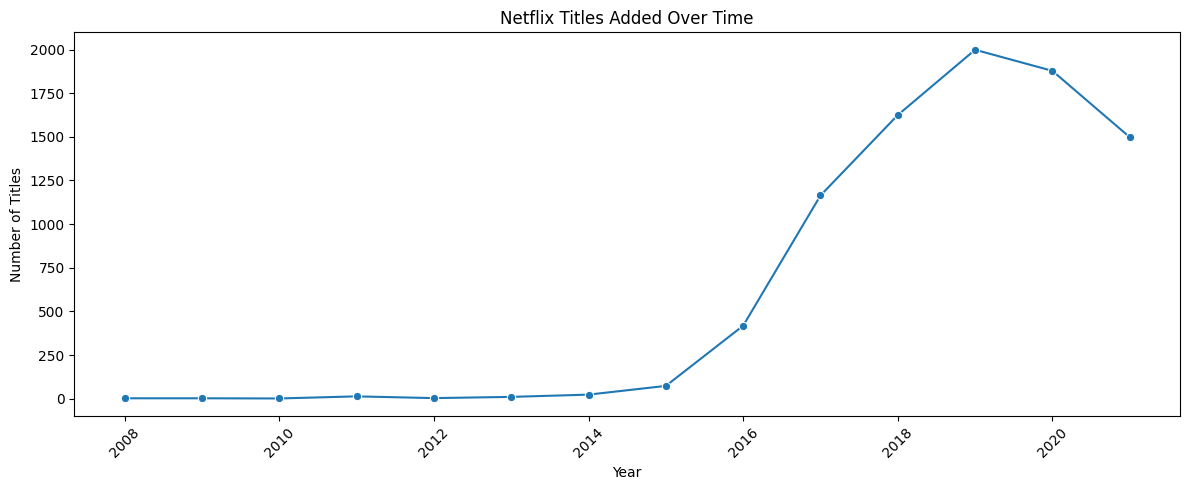

In [15]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=yearly,
    x="added_year",
    y="titles_added",
    marker="o"
)

plt.title("Netflix Titles Added Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [19]:
yearly.sort_values("titles_added", ascending=False).head(5)

,added_year,titles_added
11,2019.0,1999
12,2020.0,1878
10,2018.0,1625
13,2021.0,1498
9,2017.0,1164


### Finding

The number of Netflix titles added varied across the years. The highest
number of titles was added in 2019, while other years showed lower
levels of content additions. This indicates that Netflix's catalog
expansion was not uniform over time.

## Question 2
### What types and genres dominate Netflix's content library?

This analysis compares Movies and TV Shows and identifies the most common genres in the Netflix catalog.

Movies vs TV Shows:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Percentage of each content type:
type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: float64


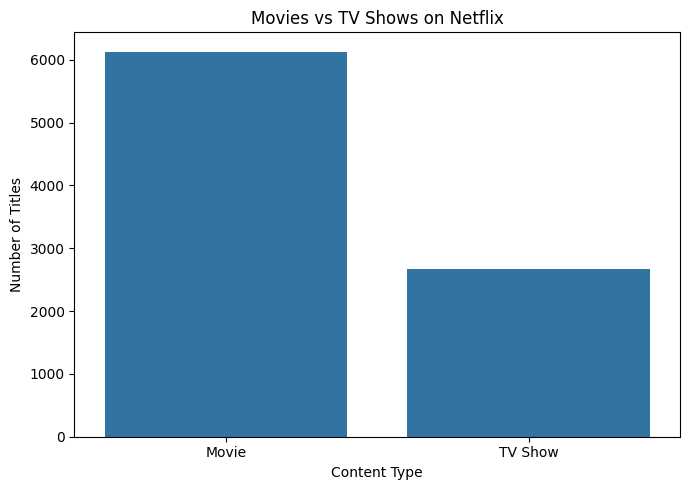


Top 10 Genres:
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


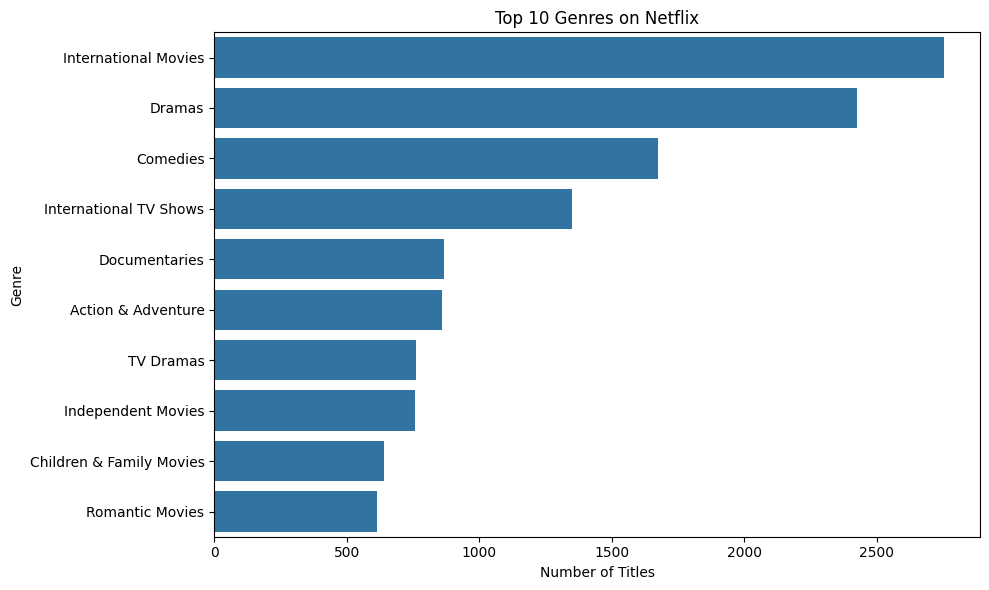

In [17]:
# -----------------------------
# Question 2: Content Types
# -----------------------------

# Count Movies and TV Shows
type_counts = df["type"].value_counts()

print("Movies vs TV Shows:")
print(type_counts)

# Calculate percentages
type_percentage = df["type"].value_counts(normalize=True) * 100

print("\nPercentage of each content type:")
print(type_percentage.round(2))


# Plot Movies vs TV Shows
plt.figure(figsize=(7, 5))

sns.barplot(
    x=type_counts.index,
    y=type_counts.values
)

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()


# -----------------------------
# Top Genres
# -----------------------------

# Split multiple genres and count them
genres = (
    df["listed_in"]
    .dropna()
    .str.split(", ")
    .explode()
)

genre_counts = genres.value_counts()

print("\nTop 10 Genres:")
print(genre_counts.head(10))


# Plot top 10 genres
top_genres = genre_counts.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

### Finding

Movies represent 69.62% of the Netflix catalog, while TV Shows represent
30.38%. This shows that Movies/TV Shows form the larger share of the
publicly listed catalog.

Among the genres, International Movies is the most frequently listed category,
followed by Dramas  and Comedies. These genres therefore have a strong
presence in Netflix's catalog.

However, genre frequency should not be interpreted as popularity because
the dataset does not contain viewer or streaming data.

## Question 3
### Which countries contribute the most titles to Netflix's content library?

This analysis identifies the countries most frequently associated with Netflix titles and examines the geographic distribution of the catalog.

Top 10 Countries:
country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64


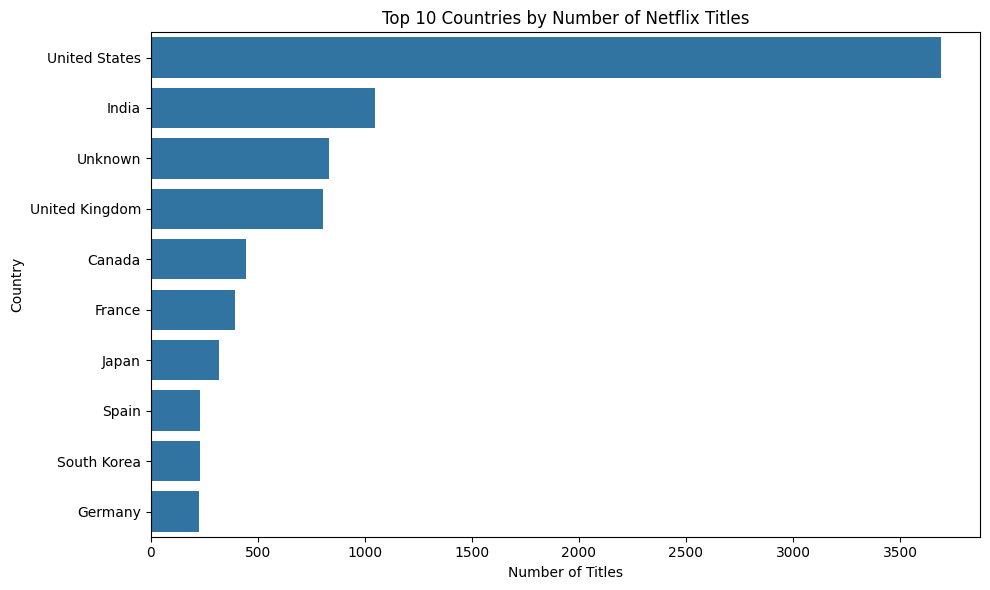

In [18]:
# -----------------------------
# Question 3: Country Analysis
# -----------------------------

# Split multiple countries listed in one row
countries = (
    df["country"]
    .dropna()
    .str.split(", ")
    .explode()
)

# Count titles associated with each country
country_counts = countries.value_counts()

print("Top 10 Countries:")
print(country_counts.head(10))


# Plot top 10 countries
top_countries = country_counts.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

### Finding

United Staes has the highest number of titles associated with it,
followed by India and United kingdom. This indicates that Netflix's
catalog has a strong geographic contribution from these countries.

However, a title can be associated with multiple countries, so these
counts represent title-country associations rather than unique
productions.